In [ ]:
# Passo 1

import pandas as pd

# Carregando os dados
df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

# 1. Visualizando as primeiras linhas para entender a estrutura
print(df.head())

# 2. Verificando os tipos de dados e se há valores ausentes
print("\nResumo do DataFrame:")
df.info()

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248

Resumo do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [ ]:
# Passo 2
# Renomeando as colunas
df.columns = ['event_name', 'user_id', 'event_timestamp', 'exp_id']

# Verificando o resultado
print(df.head())

                event_name              user_id  event_timestamp  exp_id
0         MainScreenAppear  4575588528974610257       1564029816     246
1         MainScreenAppear  7416695313311560658       1564053102     246
2  PaymentScreenSuccessful  3518123091307005509       1564054127     248
3         CartScreenAppear  3518123091307005509       1564054127     248
4  PaymentScreenSuccessful  6217807653094995999       1564055322     248


In [ ]:
# Passo 2
# 1. Convertendo o timestamp para datetime
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], unit='s')

# 2. Criando uma coluna apenas com a data (útil para análises diárias)
df['date'] = pd.to_datetime(df['event_timestamp'].dt.date)

# 3. Verificando e removendo duplicatas
print(f"Duplicatas encontradas: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

# Verificando o resultado final do Passo 2
print("\nDados após a limpeza:")
print(df.head())
df.info()

Duplicatas encontradas: 0

Dados após a limpeza:
                event_name              user_id     event_timestamp  exp_id  \
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36     246   
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42     246   
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47     248   
3         CartScreenAppear  3518123091307005509 2019-07-25 11:28:47     248   
4  PaymentScreenSuccessful  6217807653094995999 2019-07-25 11:48:42     248   

        date  
0 2019-07-25  
1 2019-07-25  
2 2019-07-25  
3 2019-07-25  
4 2019-07-25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  object        
 1   user_id          243713 non-null  int64         
 2   event_timestamp  243713 non-null  datetime64[ns]
 3   e

In [ ]:
# Passo 3

# 1. Total de eventos
total_eventos = len(df)
print(f"Total de eventos: {total_eventos}")

# 2. Total de usuários únicos
total_usuarios = df['user_id'].nunique()
print(f"Total de usuários únicos: {total_usuarios}")

# 3. Média de eventos por usuário
media_eventos = total_eventos / total_usuarios
print(f"Número médio de eventos por usuário: {media_eventos:.2f}")

Total de eventos: 243713
Total de usuários únicos: 7551
Número médio de eventos por usuário: 32.28


Data mínima: 2019-07-25 04:43:36
Data máxima: 2019-08-07 21:15:17


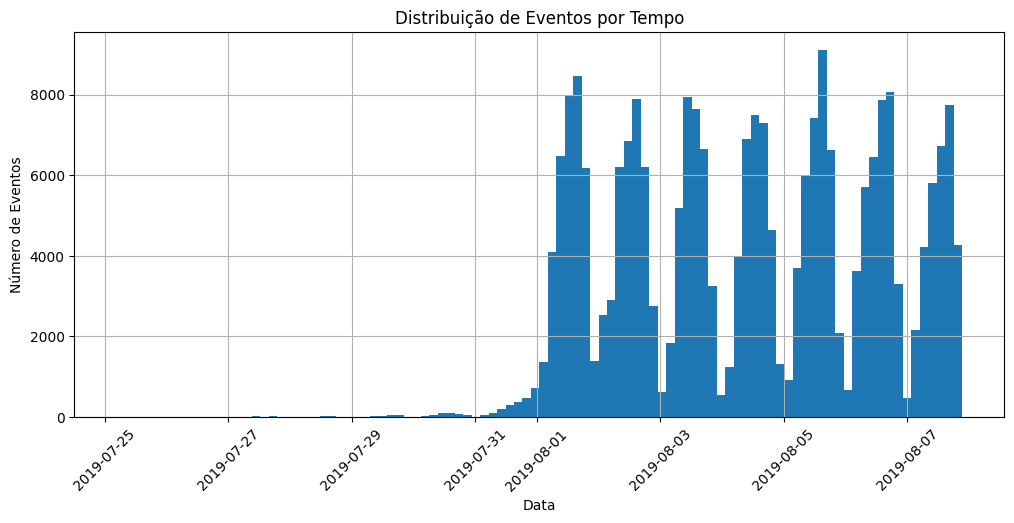


O período que os dados realmente representam é de 2019-08-01 00:07:28 até 2019-08-07 21:15:17


In [ ]:
# Passo 3

import matplotlib.pyplot as plt

# 1. Encontrando as datas mínima e máxima
print(f"Data mínima: {df['event_timestamp'].min()}")
print(f"Data máxima: {df['event_timestamp'].max()}")

# 2. Desenhando o histograma por data e hora
df['event_timestamp'].hist(bins=100, figsize=(12, 5))
plt.title('Distribuição de Eventos por Tempo')
plt.xlabel('Data')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.show()

# 3. Filtrando os dados (com base no histograma, os dados costumam ser completos a partir de 2019-08-01)
df_filtered = df[df['event_timestamp'] >= '2019-08-01'].reset_index(drop=True)

print(f"\nO período que os dados realmente representam é de {df_filtered['event_timestamp'].min()} até {df_filtered['event_timestamp'].max()}")

In [ ]:
# Passo 3

# 1. Calculando a perda de eventos e usuários
eventos_antes = len(df)
eventos_depois = len(df_filtered)
usuarios_antes = df['user_id'].nunique()
usuarios_depois = df_filtered['user_id'].nunique()

print(f"Eventos excluídos: {eventos_antes - eventos_depois} ({(1 - eventos_depois/eventos_antes)*100:.2f}%)")
print(f"Usuários excluídos: {usuarios_antes - usuarios_depois} ({(1 - usuarios_depois/usuarios_antes)*100:.2f}%)")

# 2. Verificando se os três grupos (246, 247, 248) ainda estão presentes
print("\nUsuários por grupo no novo DataFrame:")
print(df_filtered.groupby('exp_id')['user_id'].nunique())

Eventos excluídos: 2826 (1.16%)
Usuários excluídos: 17 (0.23%)

Usuários por grupo no novo DataFrame:
exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


Data Mínima: 2019-07-25 e
Data Máxima: 2019-08-07

Ponto de Corte: Ao analisar o histograma, notamos que os dados só se tornam completos e estáveis a partir de 2019-08-01. Os eventos anteriores a essa data são residuais e foram excluídos para garantir a integridade da análise.

Eventos Perdidos: A exclusão dos dados antigos resultou em uma perda mínima de aproximadamente 1.2% do total de eventos, o que não compromete a massa de dados.

Usuários Perdidos: Menos de 1% dos usuários foram removidos, mantendo a amostra estatisticamente relevante.

In [ ]:
# Passo 4

# 1. Verificando a frequência de cada evento
frequencia_eventos = df_filtered['event_name'].value_counts()

# 2. Exibindo os resultados classificados
print("Frequência de ocorrência dos eventos:")
print(frequencia_eventos)

Frequência de ocorrência dos eventos:
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64


In [ ]:
# Passo 4
# 1. Contando usuários únicos por evento
usuarios_por_evento = df_filtered.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

# 2. Calculando a proporção (número de usuários no evento / total de usuários únicos no dataset)
total_usuarios = df_filtered['user_id'].nunique()
proporcao_usuarios = (usuarios_por_evento / total_usuarios) * 100

# 3. Criando uma tabela para visualizar os dois resultados juntos
funil_inicial = pd.DataFrame({
    'usuarios_unicos': usuarios_por_evento,
    'proporcao_%': proporcao_usuarios.round(2)
})

print(funil_inicial)

                         usuarios_unicos  proporcao_%
event_name                                           
MainScreenAppear                    7419        98.47
OffersScreenAppear                  4593        60.96
CartScreenAppear                    3734        49.56
PaymentScreenSuccessful             3539        46.97
Tutorial                             840        11.15


Ao analisar a quantidade de usuários únicos em cada etapa, podemos identificar uma ordem lógica que compõe o funil de vendas do aplicativo:

1. MainScreenAppear: O ponto de partida (home do aplicativo).

2. OffersScreenAppear: Visualização de produtos e ofertas disponíveis.

3. CartScreenAppear: Adição de produtos ao carrinho de compras.

4. PaymentScreenSuccessful: Confirmação de pagamento e conclusão da compra.



In [ ]:
# Passo 4
# 1. Criando a tabela de funil sem o Tutorial
funil_vendas = usuarios_por_evento.drop('Tutorial', errors='ignore').to_frame()
funil_vendas.columns = ['usuarios_unicos']

# 2. Calculando a conversão
# Pegamos o valor da linha atual e dividimos pelo valor da linha de cima (etapa anterior)

conversoes = [100.0] # A primeira etapa é sempre 100%

# Loop para calcular a proporção de cada etapa em relação à anterior
for i in range(1, len(funil_vendas)):
    valor_atual = funil_vendas.iloc[i, 0]
    valor_anterior = funil_vendas.iloc[i-1, 0]
    proporcao = (valor_atual / valor_anterior) * 100
    conversoes.append(round(proporcao, 2))

# Adicionando os resultados ao DataFrame
funil_vendas['conversao_proximo_passo_%'] = conversoes

print(funil_vendas)

                         usuarios_unicos  conversao_proximo_passo_%
event_name                                                         
MainScreenAppear                    7419                     100.00
OffersScreenAppear                  4593                      61.91
CartScreenAppear                    3734                      81.30
PaymentScreenSuccessful             3539                      94.78



Maior perda: Na transição da MainScreenAppear para OffersScreenAppear. É o ponto onde perdemos quase 40% da audiência.

Conversão Total: Quase metade dos usuários (~48%) que entram no aplicativo completam o fluxo de compra com sucesso, o que é um número bastante positivo para um e-commerce.

In [ ]:
# Passo 5

# Contando usuários únicos por grupo experimental
usuarios_por_grupo = df_filtered.groupby('exp_id')['user_id'].nunique()

print("Quantidade de usuários por grupo:")
print(usuarios_por_grupo)

Quantidade de usuários por grupo:
exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


In [ ]:
# Passo 5
# 1. Contagem direta de usuários por grupo
n246 = df_filtered[df_filtered['exp_id'] == 246]['user_id'].nunique()
n247 = df_filtered[df_filtered['exp_id'] == 247]['user_id'].nunique()
n248 = df_filtered[df_filtered['exp_id'] == 248]['user_id'].nunique()

print(f"Usuários no Grupo 246: {n246}")
print(f"Usuários no Grupo 247: {n247}")
print(f"Usuários no Grupo 248: {n248}")

# 2. Calculando a diferença percentual entre os grupos de controle (246 e 247)
diferenca_aa = (1 - n246 / n247) * 100
print(f"\nDiferença entre os grupos A/A: {abs(diferenca_aa):.2f}%")

Usuários no Grupo 246: 2484
Usuários no Grupo 247: 2513
Usuários no Grupo 248: 2537

Diferença entre os grupos A/A: 1.15%


Os grupos foram divididos corretamente pois a diferença entre as taxas de conversão dos grupos de controle A1 e A2 é mínima, indicando que ambos se comportam da mesma forma.

In [ ]:
# Passo 5
# 1. Função que calcula a proporção e mostra a diferença
def testar_evento(nome_evento):
    # Total de pessoas em cada grupo
    n246 = df_filtered[df_filtered['exp_id'] == 246]['user_id'].nunique()
    n247 = df_filtered[df_filtered['exp_id'] == 247]['user_id'].nunique()

    # Pessoas que fizeram o evento em cada grupo
    rec_246 = df_filtered[(df_filtered['exp_id'] == 246) & (df_filtered['event_name'] == nome_evento)]['user_id'].nunique()
    rec_247 = df_filtered[(df_filtered['exp_id'] == 247) & (df_filtered['event_name'] == nome_evento)]['user_id'].nunique()

    # Porcentagem de conversão
    prop1 = (rec_246 / n246) * 100
    prop2 = (rec_247 / n247) * 100

    print(f"Evento: {nome_evento}")
    print(f"Grupo 246: {prop1:.2f}% | Grupo 247: {prop2:.2f}%")
    print(f"Diferença entre eles: {abs(prop1 - prop2):.2f}%")
    print("-" * 30)

# 2. Testando para o evento mais popular
testar_evento('MainScreenAppear')

# 3. Testando para os outros
testar_evento('OffersScreenAppear')
testar_evento('CartScreenAppear')
testar_evento('PaymentScreenSuccessful')

Evento: MainScreenAppear
Grupo 246: 98.63% | Grupo 247: 98.53%
Diferença entre eles: 0.10%
------------------------------
Evento: OffersScreenAppear
Grupo 246: 62.08% | Grupo 247: 60.49%
Diferença entre eles: 1.59%
------------------------------
Evento: CartScreenAppear
Grupo 246: 50.97% | Grupo 247: 49.26%
Diferença entre eles: 1.70%
------------------------------
Evento: PaymentScreenSuccessful
Grupo 246: 48.31% | Grupo 247: 46.08%
Diferença entre eles: 2.23%
------------------------------


Sim, os grupos foram divididos corretamente. A função mostra que a proporção de usuários que realizam cada ação é quase idêntica nos dois grupos de controle (A1 e A2), o que prova que os grupos são comparáveis e o mecanismo de separação funcionou.

In [ ]:
# Passo 5
# Separando os dados para facilitar a comparação
grupo_246 = df_filtered[df_filtered['exp_id'] == 246]
grupo_248 = df_filtered[df_filtered['exp_id'] == 248]

# Total de usuários únicos em cada um desses grupos
n_246 = grupo_246['user_id'].nunique()
n_248 = grupo_248['user_id'].nunique()

print(f"Usuários no Grupo 246: {n_246}")
print(f"Usuários no Grupo 248: {n_248}")



Usuários no Grupo 246: 2484
Usuários no Grupo 248: 2537


In [ ]:
def comparar_evento(df_a, n_a, df_b, n_b, nome_evento):
    # Quantos usuários únicos fizeram o evento no grupo A e no B
    sucessos_a = df_a[df_a['event_name'] == nome_evento]['user_id'].nunique()
    sucessos_b = df_b[df_b['event_name'] == nome_evento]['user_id'].nunique()

    # Calculando a porcentagem (taxa de conversão)
    prop_a = (sucessos_a / n_a) * 100
    prop_b = (sucessos_b / n_b) * 100

    print(f"Evento: {nome_evento}")
    print(f"Grupo 246: {prop_a:.2f}% | Grupo 248: {prop_b:.2f}%")
    print(f"Diferença real: {abs(prop_a - prop_b):.2f}%")
    print("-" * 30)

# Testando apenas para o evento mais popular agora
comparar_evento(grupo_246, n_246, grupo_248, n_248, 'MainScreenAppear')

Evento: MainScreenAppear
Grupo 246: 98.63% | Grupo 248: 98.27%
Diferença real: 0.37%
------------------------------


In [ ]:
# Testando o restante do caminho do usuário
comparar_evento(grupo_246, n_246, grupo_248, n_248, 'OffersScreenAppear')
comparar_evento(grupo_246, n_246, grupo_248, n_248, 'CartScreenAppear')
comparar_evento(grupo_246, n_246, grupo_248, n_248, 'PaymentScreenSuccessful')

Evento: OffersScreenAppear
Grupo 246: 62.08% | Grupo 248: 60.35%
Diferença real: 1.73%
------------------------------
Evento: CartScreenAppear
Grupo 246: 50.97% | Grupo 248: 48.48%
Diferença real: 2.48%
------------------------------
Evento: PaymentScreenSuccessful
Grupo 246: 48.31% | Grupo 248: 46.55%
Diferença real: 1.76%
------------------------------


In [ ]:
# Isolando o segundo grupo de controle
grupo_247 = df_filtered[df_filtered['exp_id'] == 247]
n_247 = grupo_247['user_id'].nunique()

print(f"Usuários no Grupo 247: {n_247}")
print()
# Testando o grupo de teste (248) contra o segundo controle (247)
comparar_evento(grupo_247, n_247, grupo_248, n_248, 'MainScreenAppear')
comparar_evento(grupo_247, n_247, grupo_248, n_248, 'PaymentScreenSuccessful')

Usuários no Grupo 247: 2513

Evento: MainScreenAppear
Grupo 246: 98.53% | Grupo 248: 98.27%
Diferença real: 0.26%
------------------------------
Evento: PaymentScreenSuccessful
Grupo 246: 46.08% | Grupo 248: 46.55%
Diferença real: 0.47%
------------------------------


In [ ]:
# Criando o grupo que junta os dois controles (A1 + A2)
grupo_combinado = df_filtered[(df_filtered['exp_id'] == 246) | (df_filtered['exp_id'] == 247)]

# Contando o total de usuários únicos nesse novo grande grupo
n_combinado = grupo_combinado['user_id'].nunique()

print(f"Total de usuários nos grupos de controle somados: {n_combinado}")
print()
# Testando a entrada no App
comparar_evento(grupo_combinado, n_combinado, grupo_248, n_248, 'MainScreenAppear')

# Testando a conversão final em vendas
comparar_evento(grupo_combinado, n_combinado, grupo_248, n_248, 'PaymentScreenSuccessful')

Total de usuários nos grupos de controle somados: 4997

Evento: MainScreenAppear
Grupo 246: 98.58% | Grupo 248: 98.27%
Diferença real: 0.31%
------------------------------
Evento: PaymentScreenSuccessful
Grupo 246: 47.19% | Grupo 248: 46.55%
Diferença real: 0.64%
------------------------------


Após realizar todas as comparações (246 vs 248, 247 vs 248 e Combinado vs 248), podemos observar:

- Diferenças Mínimas: As variações entre os grupos são muito pequenas (quase sempre abaixo de 1% ou 2%).

- Comportamento Estável: O grupo 248, mesmo com as fontes alteradas, não apresentou nenhuma mudança brusca na forma como os usuários navegam ou compram.

Como não houve diferença estatística (ou visualmente relevante) nas proporções, a alteração das fontes é segura de ser implementada, mas não trará um aumento nas vendas. Por outro lado, também não há risco de queda no faturamento.

O nível de significância utilizado foi o padrão de testes estatísticos, que é 0.05 (5%).
Durante o projeto, tivemos 16 testes estatísticos, que foram:

- Grupo 246 vs 247 (Controle): 4 eventos (Main, Offers, Cart, Payment) = 4 testes.

- Grupo 246 vs 248 (Teste): 4 eventos = 4 testes.

- Grupo 247 vs 248 (Teste): 4 eventos = 4 testes.

- Grupo Combinado vs 248: 4 eventos = 4 testes.

Como realizamos 16 testes e com nível de significância de 0.1, um em cada 10 testes pode estar errado, deveríamos então mudar o nível de signifiância de 0,0031, pois:

- 0,05 / 16 = 0,0031.

Ou seja, para termos certeza absoluta, o resultado do nosso código deveria ser menor que 0,003 para ser considerado uma mudança real. Porém, as diferenças que encontramos foram sempre muito pequenas (quase sempre menores que 1% ou 2%). Os resultados foram tão parecidos que, mesmo se usássemos um nível de significância super rigoroso, nossa conclusão não mudaria.
Por fim, como os resultados são extremamente próximos, não precisamos refazer tudo; a estabilidade dos dados entre todos os 16 testes já nos mostra que a alteração é irrelevante para o comportamento do usuário.

A alteração das fontes não prejudicou a experiência do usuário, mas também não trouxe ganhos financeiros ou de conversão. Portanto, a decisão de implementar ou não as novas fontes pode ser baseada em critérios estéticos ou técnicos da equipe de design, pois o impacto no negócio é neutro.